In [1]:
import DataPrepTulips3D as DP
import mesaPlot as mp
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import numpy as np
import copy
from time import time
from PIL import Image
import os

In [16]:
d = DP.load_from_pickle("../../../example_MESA_data/DataDictFormat/single_11Msun_linear.pkl")

In [17]:
d.keys()

dict_keys(['info', 'MESA_file', 'filename_history', 'r_label', 'age', 'age_indices', 'prof_labels', 'chem_elem_labels', 't_resolution', 'r_resolution', 'data_prof_t_r', 'data_chem_t_r', 'data_r_max', 'data_t'])

In [18]:
d['data_chem_t_r'].shape, d['data_prof_t_r'].shape, d['prof_labels'], d['data_t'].keys()

((19, 500, 100),
 (5, 500, 100),
 ['mass', 'logT', 'logRho', 'he4', 'en'],
 dict_keys(['logTeff']))

# Writing out as a texture

In [47]:
d_log = DP.loadMesaData(mesa_LOGS_directory = "../../../example_MESA_data/single_11Msun/LOGS", \
                    t_resolution = 3280, r_resolution = 100,\
                    time_scale_type="log_to_end",\
                    filename_history = "history.data")

Original/new time resolution:  3280 3280
Working on profile data
Working on Chem. abundance data


In [48]:
d.keys()

dict_keys(['info', 'MESA_file', 'filename_history', 'r_label', 'age', 'age_indices', 'prof_labels', 'chem_elem_labels', 't_resolution', 'r_resolution', 'data_prof_t_r', 'data_chem_t_r', 'data_r_max', 'data_t'])

In [49]:
d['data_prof_t_r'].shape, d['prof_labels'], d['prof_labels'].index('en')

((5, 500, 100), ['mass', 'logT', 'logRho', 'he4', 'en'], 4)

In [50]:
d_en = d['data_prof_t_r'][4, :, :]

In [51]:
d_en.shape

(500, 100)

In [52]:
d['t_resolution'], d['r_resolution']

(500, 100)

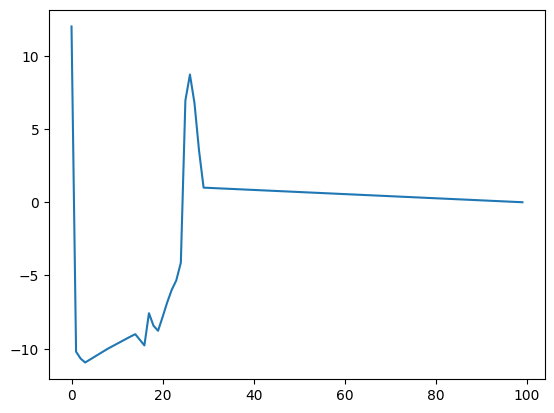

In [53]:
plt.plot(d_en[499, :])

In [54]:

def save_colormapped_texture(array, output_path, cmap_name='viridis', vmin=-10, vmax=10):
    """
    Save a 2D NumPy array as a color texture using a Matplotlib colormap.
    
    Parameters:
    -----------
    array : numpy.ndarray
        2D array of data values.
    output_path : str
        Path to save the PNG file.
    cmap_name : str
        Name of the Matplotlib colormap (e.g., 'viridis', 'plasma', 'coolwarm').
        Default is 'viridis'.
    vmin, vmax : float or None
        Min/max values for normalization. If None, uses array min/max.
    """
    
    if array.ndim != 2:
        raise ValueError(f"Expected 2D array, got {array.ndim}D array")
    
    # 1. Setup Colormap and Normalization
    # cmap = plt.get_cmap(cmap_name)
    p = mp.plot(rcparams_fixed=False)
    cmap = p.mergeCmaps([plt.cm.Purples_r, plt.cm.hot_r], [[0.0, 0.5], [0.5, 1.0]])
    
    # Create the Normalize object. 
    # If you pass specific vmin/vmax, it clamps values outside that range.
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # 2. Apply Normalization and Colormap
    # norm(array) scales data to [0, 1]
    # cmap(...) converts those scaled values to RGBA (floats 0.0-1.0)
    rgba_array = cmap(norm(array))
    
    # The result from cmap is shape (H, W, 4) with dtype float64
    # We need to check the shape just in case the input was masked or weird, 
    # but usually for a simple 2D array, this works directly.
    
    # 3. Convert to 8-bit uint8 for saving as PNG
    # Multiply by 255 and clip to [0, 255]
    uint8_array = np.clip(rgba_array * 255, 0, 255).astype(np.uint8)
    
    # 4. Save as Image
    # Mode 'RGBA' handles the 4 channels
    img = Image.fromarray(uint8_array)#, mode='RGBA')
    plt.imshow(img)
    plt.show()
    # Save with optimization
    img.save(output_path, optimize=True, compress_level=6)
    
    print(f"Texture saved successfully: {output_path}")
    print(f"   - Colormap: {cmap_name}")
    print(f"   - Data Range: {array.min():.2f} to {array.max():.2f}")
    print(f"   - Normalization Range: {norm.vmin:.2f} to {norm.vmax:.2f}")
    print(f"   - Dimensions: {img.size[0]}x{img.size[1]}")
    print(f"   - File Size: {os.path.getsize(output_path)} bytes")
    
    return output_path

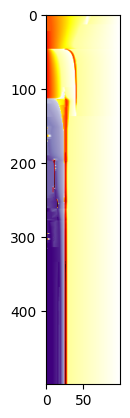

Texture saved successfully: ./test_3280x100.png
   - Colormap: viridis
   - Data Range: -11.00 to 12.00
   - Normalization Range: -10.00 to 10.00
   - Dimensions: 100x500
   - File Size: 11602 bytes


'./test_3280x100.png'

In [55]:
save_colormapped_texture(d_en, "./test_3280x100.png")

In [27]:
p = mp.plot(rcparams_fixed=False)
cmap = p.mergeCmaps([plt.cm.Purples_r, plt.cm.hot_r], [[0.0, 0.5], [0.5, 1.0]])
cmin, cmax = -10, 10 #min(value), max(value)
norm = Normalize(vmin=cmin, vmax=cmax)
# cmap(norm( list_color ))


In [29]:
cmap(norm(200))

(np.float64(0.0416), np.float64(0.0), np.float64(0.0), np.float64(1.0))